处理SOFA环境下的Liver单点控制

上游代码 -> `LiverControl.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from mpl_toolkits.mplot3d import Axes3D

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [2]:
POINTS_NUM:int = 1
num:int = 1

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_sofa_np = np.loadtxt(f'dots_sofa_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
sofa_contact_pos = np.loadtxt(f'sofa_contact_pos_list{num}.csv', delimiter=',')

In [12]:
def plot_loss(loss_np):
    plot_step_num = loss_np.shape[0]
    fig = plt.figure(figsize=(6, 3), dpi=150)
    gs = GridSpec(1, 1, figure=fig)

    step_num = loss_np.shape[0]
    axs_loss = fig.add_subplot(gs[0, :])
    axs_loss.plot(loss_np[:], marker='.', markerfacecolor='white', linestyle='-', linewidth=2, color='black')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, plot_step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(20))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    axs_loss.grid(True)

    plt.tight_layout()
    fig.savefig(f'loss.png', transparent=True, dpi=300)

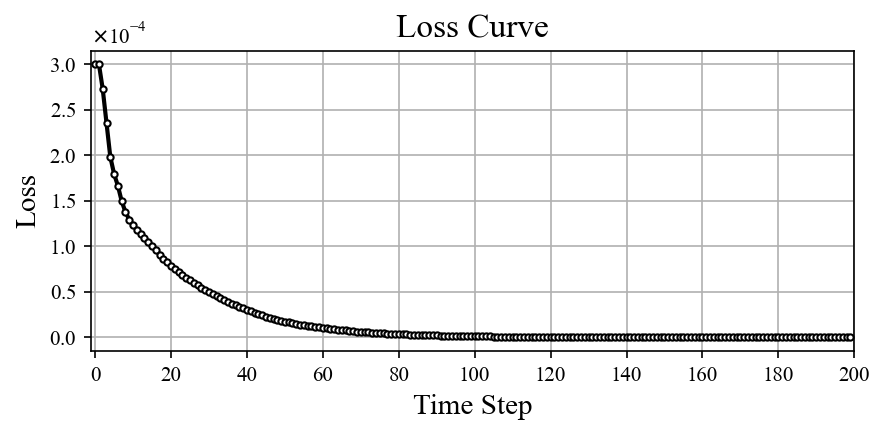

In [13]:
plot_loss(loss_np)

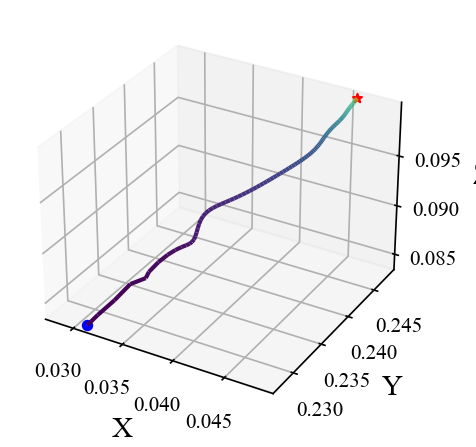

In [23]:
fig = plt.figure(figsize=(5, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

# 选择点的索引
indices = np.arange(len(sofa_contact_pos[:,0]))

# 计算颜色渐变
t = np.linspace(0, 1, len(sofa_contact_pos[:,0]))  # 颜色映射的变量，假设是时间
norm = plt.Normalize(t.min(), t.max())
colors = cm.viridis(norm(t))  # 使用 viridis 颜色映射

# 创建 3D 坐标点
rob_pose_xyz = np.stack([sofa_contact_pos[:,0][indices], sofa_contact_pos[:,1][indices], sofa_contact_pos[:,2][indices]], axis=1).reshape(-1, 1, 3)

# 创建线段（每一段是连续的两个点之间的线段）
segments = np.concatenate([rob_pose_xyz[:-1], rob_pose_xyz[1:]], axis=1)

# 使用 Line3DCollection 绘制具有渐变色的轨迹线
lc = Line3DCollection(segments, colors=colors, linewidth=2, zorder=1)

ax_traj = fig.add_subplot(gs[0, 0], projection='3d')
ax_traj.add_collection(lc, autolim=True)

ax_traj.scatter(rob_pose_xyz[0, 0, 0], rob_pose_xyz[0, 0, 1], rob_pose_xyz[0, 0, 2], c='blue', s=20, marker='o', label='Start Point', zorder=3)
ax_traj.scatter(rob_pose_xyz[-1, 0, 0], rob_pose_xyz[-1, 0, 1], rob_pose_xyz[-1, 0, 2], c='red', s=20, marker='*', label='End Point', zorder=3)

ax_traj.set_xlim([np.min(sofa_contact_pos[:,0]), np.max(sofa_contact_pos[:,0])])
ax_traj.set_ylim([np.min(sofa_contact_pos[:,1]), np.max(sofa_contact_pos[:,1])])
ax_traj.set_zlim([np.min(sofa_contact_pos[:,2]), np.max(sofa_contact_pos[:,2])])

ax_traj.set_xlabel('X', fontsize=14, fontname='Times New Roman')
ax_traj.set_ylabel('Y', fontsize=14, fontname='Times New Roman')
ax_traj.set_zlabel('Z', fontsize=14, fontname='Times New Roman')

# ax_traj.set_title('Robot Tool Trajectory', fontsize=16, fontname='Times New Roman')
ax_traj.set_aspect('equal', 'datalim')

plt.tight_layout()
fig.savefig(f'trajectory.png', transparent=True, dpi=300)

In [29]:
POINTS_NUM:int = 1
num:int = 2

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_sofa_np = np.loadtxt(f'dots_sofa_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
sofa_contact_pos = np.loadtxt(f'sofa_contact_pos_list{num}.csv', delimiter=',')

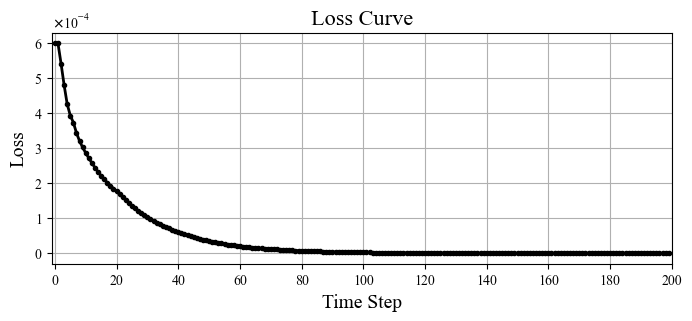

In [13]:
plot_loss(loss_np)

---
用于论文绘图

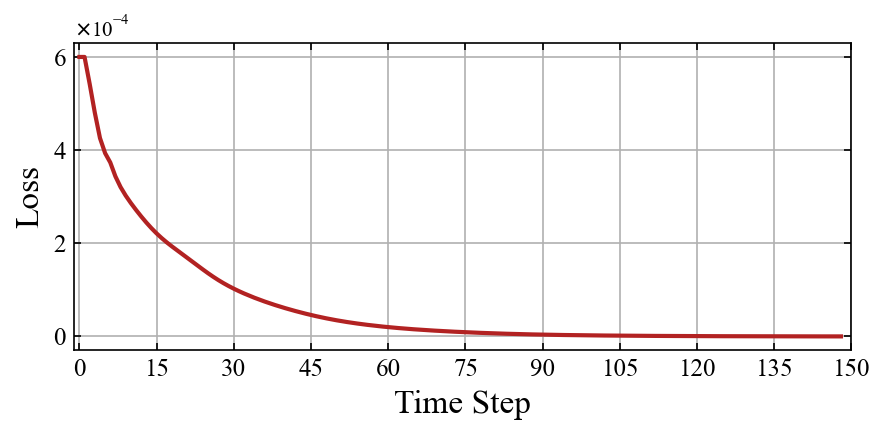

In [84]:
# plot_step_num = loss_np.shape[0]
plot_step_num = 150
fig = plt.figure(figsize=(6, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)

step_num = loss_np.shape[0]
axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num-1], marker='', markerfacecolor='white', linestyle='-', linewidth=2, color='firebrick')
# axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(15))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
axs_loss.grid(True)

plt.tight_layout()
fig.savefig(f'liver-node-loss.svg', transparent=True, dpi=300, bbox_inches='tight')

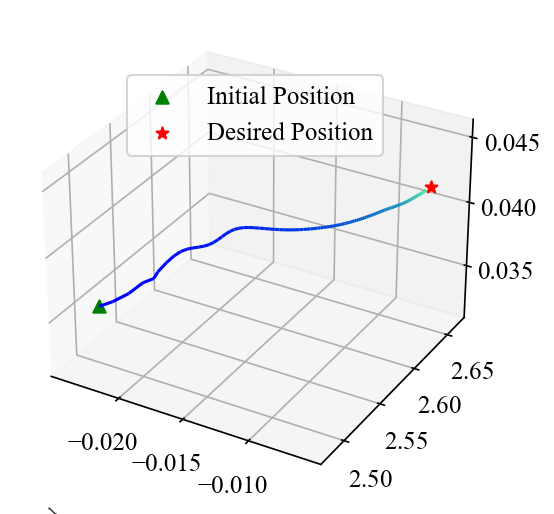

In [83]:
inital_pos = dot_sofa_np[0,:]
desired_pos = inital_pos + np.array([0.02, 0.01, 0.01])

plot_step_num = 150
t = np.linspace(0, 1, plot_step_num)
norm = plt.Normalize(t.min(), t.max())
colors = cm.winter(norm(t))

dot_pos_xyz = np.stack([dot_sofa_np[:plot_step_num,0], dot_sofa_np[:plot_step_num,1], dot_sofa_np[:plot_step_num,2]], axis=1).reshape(-1, 1, 3)
segments = np.concatenate([dot_pos_xyz[:-1], dot_pos_xyz[1:]], axis=1)
lc = Line3DCollection(segments, color=colors, linewidth=1.5, zorder=2)

fig_marker = plt.figure(figsize=(4, 3.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_marker)

ax_marker = fig_marker.add_subplot(gs[0, 0], projection='3d')
ax_marker.add_collection(lc, autolim=False)
# ax_marker.plot(dot_sofa_np[:,0], dot_sofa_np[:,1], dot_sofa_np[:,2], label='3D Trajectory')

ax_marker.set_xlim([np.min(dot_sofa_np[:,0]), np.max(dot_sofa_np[:,0])])
ax_marker.set_ylim([np.min(dot_sofa_np[:,1]), np.max(dot_sofa_np[:,1])])
ax_marker.set_zlim([np.min(dot_sofa_np[:,2]), np.max(dot_sofa_np[:,2])])
ax_marker.scatter(inital_pos[0], inital_pos[1], inital_pos[2], marker='^', s=35, c='g', label='Initial Position', zorder=10)
ax_marker.scatter(desired_pos[0], desired_pos[1], desired_pos[2], marker='*', s=35, c='red', label='Desired Position')
# ax_marker.set_title('Marker Point Trajectory', fontsize=16, fontname='Times New Roman')

# ax_marker.set_xlabel('X', fontsize=16, fontname='Times New Roman')
# ax_marker.set_ylabel('Y', fontsize=16, fontname='Times New Roman')
# ax_marker.set_zlabel('Z', fontsize=16, fontname='Times New Roman')
ax_marker.xaxis.set_major_locator(MultipleLocator(0.005))
ax_marker.yaxis.set_major_locator(MultipleLocator(0.005))
ax_marker.zaxis.set_major_locator(MultipleLocator(0.005))
ax_marker.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)

ax_marker.set_aspect('equal', 'datalim')
ax_marker.tick_params(axis='both', which='major', labelsize=12)
ax_marker.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=1)

fig_marker.tight_layout()
fig_marker.savefig(f'liver-node-marker-traj.svg', transparent=True, dpi=300, bbox_inches='tight')

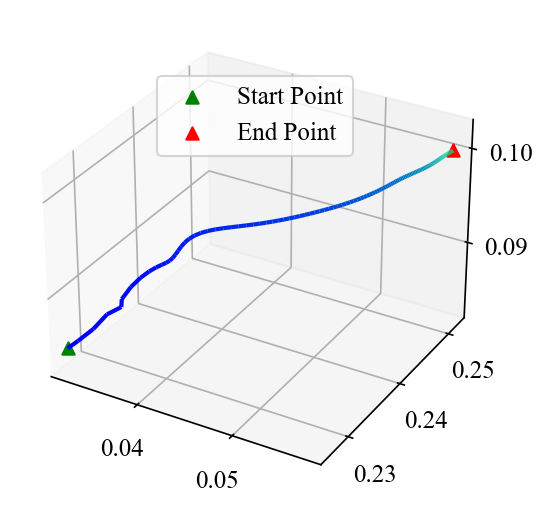

In [86]:
indices = np.arange(len(sofa_contact_pos[:150,0]))

rob_pose_xyz = np.stack([sofa_contact_pos[:,0][indices], sofa_contact_pos[:,1][indices], sofa_contact_pos[:,2][indices]], axis=1).reshape(-1, 1, 3)
segments = np.concatenate([rob_pose_xyz[:-1], rob_pose_xyz[1:]], axis=1)
lc = Line3DCollection(segments, colors=colors, linewidth=2)

fig_rob = plt.figure(figsize=(4, 3.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_rob)
ax_rob = fig_rob.add_subplot(gs[0, 0], projection='3d')
ax_rob.add_collection(lc, autolim=True)

ax_rob.scatter(rob_pose_xyz[0, 0, 0], rob_pose_xyz[0, 0, 1], rob_pose_xyz[0, 0, 2], c='green', s=35, marker='^', label='Start Point', zorder=3)
ax_rob.scatter(rob_pose_xyz[-1, 0, 0], rob_pose_xyz[-1, 0, 1], rob_pose_xyz[-1, 0, 2], c='red', s=35, marker='^', label='End Point', zorder=3)

ax_rob.set_xlim([np.min(sofa_contact_pos[:,0]), np.max(sofa_contact_pos[:,0])])
ax_rob.set_ylim([np.min(sofa_contact_pos[:,1]), np.max(sofa_contact_pos[:,1])])
ax_rob.set_zlim([np.min(sofa_contact_pos[:,2]), np.max(sofa_contact_pos[:,2])])

# ax_rob.set_xlabel('X', fontsize=16, fontname='Times New Roman')
# ax_rob.set_ylabel('Y', fontsize=16, fontname='Times New Roman')
# ax_rob.set_zlabel('Z', fontsize=16, fontname='Times New Roman')
ax_rob.xaxis.set_major_locator(MultipleLocator(0.01))
ax_rob.yaxis.set_major_locator(MultipleLocator(0.01))
ax_rob.zaxis.set_major_locator(MultipleLocator(0.01))

# ax_rob.set_title('Robot Tool Trajectory', fontsize=16, fontname='Times New Roman')
ax_rob.set_aspect('equal', 'datalim')
ax_rob.tick_params(axis='both', which='major', labelsize=12)
ax_rob.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=1)

fig_rob.tight_layout()
fig_rob.savefig(f'liver-node-rob-traj.svg', transparent=True, dpi=300, bbox_inches='tight')